# Task 3: Linear Regression

## 1. Objective

Linear regression models a continuous target as a linear combination of one or more predictors. **Simple linear regression** uses one predictor; **multiple linear regression** uses several predictors at once. This notebook uses the supplied housing dataset to build, evaluate, interpret, and diagnose both approaches.

## 2. Dataset Overview

This project uses **Housing 2.csv**. The overview below is generated from the loaded file so that the stated observation count, feature count, and target are reproducible rather than assumed.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda value: f'{value:,.3f}')


## 3. Import Libraries

Pandas and NumPy support data handling, Matplotlib/Seaborn provide visualizations, scikit-learn supplies the regression workflow and metrics, and Statsmodels is used only to calculate VIF for the multicollinearity check.

## 4. Load Dataset

The path is relative to the notebook directory. A small fallback keeps the notebook usable when launched from the project root without embedding a user-specific absolute path.

In [2]:
relative_path = Path('../data/Housing 2.csv')
if relative_path.exists():
    data_path = relative_path
elif Path('data/Housing 2.csv').exists():
    data_path = Path('data/Housing 2.csv')
else:
    raise FileNotFoundError('Could not find data/Housing 2.csv from the current working directory.')

df = pd.read_csv(data_path)
target_column = 'price'
if target_column not in df.columns:
    raise ValueError(f"Expected target column '{target_column}' was not found. Available columns: {df.columns.tolist()}")

display(Markdown(f"**Loaded:** `{data_path.as_posix()}`  \n+**Observations:** {df.shape[0]}  \n+**Columns:** {df.shape[1]} (including target)  \n+**Target variable:** `{target_column}`"))
display(df.head())
display(df.tail())
print('Shape:', df.shape)


**Loaded:** `../data/Housing 2.csv`  
+**Observations:** 545  
+**Columns:** 13 (including target)  
+**Target variable:** `price`

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


Shape: (545, 13)


## 5. Initial Data Inspection

The following checks identify data types, descriptive statistics, missing entries, duplicate records, and category cardinality before modelling.

In [3]:
df.info()
display(df.describe(include='all').T)

missing_values = df.isna().sum().rename('Missing Values').to_frame()
duplicate_rows = int(df.duplicated().sum())
categorical_columns = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

display(missing_values)
print(f'Duplicate rows: {duplicate_rows}')
print('Categorical columns:', categorical_columns)
print('Numerical columns:', numerical_columns)
display(df[categorical_columns].nunique().rename('Unique Values').to_frame())


<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.000,NaN,NaN,NaN,"4,766,729.248","1,870,439.616","1,750,000.000","3,430,000.000","4,340,000.000","5,740,000.000","13,300,000.000"
area,545.000,NaN,NaN,NaN,"5,150.541","2,170.141","1,650.000","3,600.000","4,600.000","6,360.000","16,200.000"
bedrooms,545.000,NaN,NaN,NaN,2.965,0.738,1.000,2.000,3.000,3.000,6.000
bathrooms,545.000,NaN,NaN,NaN,1.286,0.502,1.000,1.000,1.000,2.000,4.000
stories,545.000,NaN,NaN,NaN,1.806,0.867,1.000,1.000,2.000,2.000,4.000
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Missing Values
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


Duplicate rows: 0
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
Numerical columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


,Unique Values
mainroad,2
guestroom,2
basement,2
hotwaterheating,2
airconditioning,2
prefarea,2
furnishingstatus,3


## 6. Data Preprocessing

The inspection results determine the preprocessing choices. The notebook removes missing rows or duplicate rows only if they exist, preserves all useful non-ID predictors, and one-hot encodes categorical predictors with one reference level dropped. The target is explicitly excluded from the feature matrix.

In [4]:
model_df = df.copy()
rows_before = len(model_df)
model_df = model_df.dropna().drop_duplicates().copy()
rows_after = len(model_df)

X_raw = model_df.drop(columns=[target_column])
y = model_df[target_column]

# The dataset contains no ID/index-style predictor; all supplied predictors are retained.
X_multiple = pd.get_dummies(X_raw, columns=categorical_columns, drop_first=True, dtype=float)

display(Markdown(
    f"**Preprocessing summary:** removed {rows_before - rows_after} rows due to missing values or duplicates; "
    f"encoded {len(categorical_columns)} categorical columns; retained {X_multiple.shape[1]} predictors. "
    "The target `price` is not present in the feature matrix."
))
display(X_multiple.head())


**Preprocessing summary:** removed 0 rows due to missing values or duplicates; encoded 7 categorical columns; retained 13 predictors. The target `price` is not present in the feature matrix.

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1.000,0.000,0.000,0.000,1.000,1.000,0.000,0.000
1,8960,4,4,4,3,1.000,0.000,0.000,0.000,1.000,0.000,0.000,0.000
2,9960,3,2,2,2,1.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000
3,7500,4,2,2,3,1.000,0.000,1.000,0.000,1.000,1.000,0.000,0.000
4,7420,4,1,2,2,1.000,1.000,1.000,0.000,1.000,0.000,0.000,0.000


## 7. Simple Linear Regression

Among the numerical predictors, the feature with the largest absolute correlation with `price` is selected. This is a data-informed choice, rather than an arbitrary one. The split uses 80% training data and 20% test data with `random_state=42`.

In [5]:
numeric_predictors = [column for column in numerical_columns if column != target_column]
target_correlations = model_df[numeric_predictors + [target_column]].corr()[target_column].drop(target_column)
simple_feature = target_correlations.abs().idxmax()

display(target_correlations.sort_values(key=lambda s: s.abs(), ascending=False).rename('Correlation with price').to_frame())
display(Markdown(f"**Selected simple-regression feature:** `{simple_feature}` (correlation with `price`: {target_correlations[simple_feature]:.3f})."))

X_simple = model_df[[simple_feature]]
X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)
simple_model = LinearRegression()
simple_model.fit(X_simple_train, y_simple_train)
simple_predictions = simple_model.predict(X_simple_test)

def metrics_frame(actual, predicted):
    mse = mean_squared_error(actual, predicted)
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'R²': r2_score(actual, predicted),
    }

simple_metrics = metrics_frame(y_simple_test, simple_predictions)
display(pd.DataFrame([simple_metrics], index=['Simple Linear Regression']).round(3))


,Correlation with price
area,0.536
bathrooms,0.518
stories,0.421
parking,0.384
bedrooms,0.366


**Selected simple-regression feature:** `area` (correlation with `price`: 0.536).

,MAE,MSE,RMSE,R²
Simple Linear Regression,"1,474,748.134","3,675,286,604,768.185","1,917,103.702",0.273


## 8. Simple Linear Regression Visualization

The scatter plot shows the held-out observations. The line is fitted using only the training split and then plotted across the observed feature range.

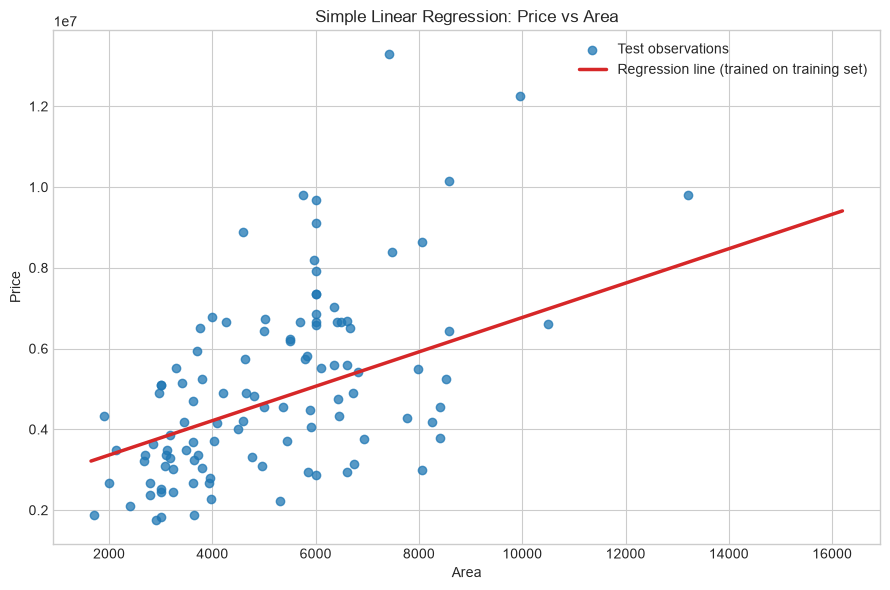

In [6]:
plot_x = np.linspace(X_simple[simple_feature].min(), X_simple[simple_feature].max(), 200).reshape(-1, 1)
plot_line = simple_model.predict(plot_x)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(X_simple_test[simple_feature], y_simple_test, alpha=0.75, label='Test observations', color='#1f77b4')
ax.plot(plot_x, plot_line, color='#d62728', linewidth=2.5, label='Regression line (trained on training set)')
ax.set_xlabel(simple_feature.title())
ax.set_ylabel(target_column.title())
ax.set_title(f'Simple Linear Regression: {target_column.title()} vs {simple_feature.title()}')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Simple Regression Coefficient Interpretation

The slope describes the expected change in `price` for a one-unit increase in the selected feature according to this one-predictor model. It describes an association in the fitted data, not proof of causation.

In [7]:
simple_intercept = simple_model.intercept_
simple_coefficient = simple_model.coef_[0]
display(pd.DataFrame({'Term': ['Intercept', simple_feature], 'Coefficient': [simple_intercept, simple_coefficient]}).round(3))
display(Markdown(
    f"The estimated coefficient for **{simple_feature}** is **{simple_coefficient:,.2f}**. "
    f"For a one-unit increase in `{simple_feature}`, the model predicts a {('increase' if simple_coefficient >= 0 else 'decrease')} "
    f"of about **{abs(simple_coefficient):,.2f}** in `{target_column}`. "
    f"The intercept is **{simple_intercept:,.2f}**, the model prediction when `{simple_feature}` is zero; its practical interpretation depends on whether zero is meaningful in this dataset."
))


,Term,Coefficient
0,Intercept,"2,512,254.264"
1,area,425.730


The estimated coefficient for **area** is **425.73**. For a one-unit increase in `area`, the model predicts a increase of about **425.73** in `price`. The intercept is **2,512,254.26**, the model prediction when `area` is zero; its practical interpretation depends on whether zero is meaningful in this dataset.

## 10. Multiple Linear Regression

The multiple-regression model uses all available non-target predictors: six numerical housing characteristics plus one-hot encoded categorical characteristics. There are no ID columns to exclude. This allows the model to estimate each coefficient while holding the other included predictors constant.

In [8]:
X_multiple_train, X_multiple_test, y_multiple_train, y_multiple_test = train_test_split(
    X_multiple, y, test_size=0.2, random_state=42
)
multiple_model = LinearRegression()
multiple_model.fit(X_multiple_train, y_multiple_train)
multiple_predictions = multiple_model.predict(X_multiple_test)
multiple_metrics = metrics_frame(y_multiple_test, multiple_predictions)

display(pd.DataFrame([multiple_metrics], index=['Multiple Linear Regression']).round(3))
print('Multiple-regression predictors:', ', '.join(X_multiple.columns))


,MAE,MSE,RMSE,R²
Multiple Linear Regression,"970,043.404","1,754,318,687,330.664","1,324,506.960",0.653


Multiple-regression predictors: area, bedrooms, bathrooms, stories, parking, mainroad_yes, guestroom_yes, basement_yes, hotwaterheating_yes, airconditioning_yes, prefarea_yes, furnishingstatus_semi-furnished, furnishingstatus_unfurnished


## 11. Model Comparison

Lower MAE, MSE, and RMSE indicate smaller prediction errors; higher R² indicates more of the test-set variation is explained. The comparison is based on the same 80/20 split.

In [9]:
comparison = pd.DataFrame(
    [simple_metrics, multiple_metrics],
    index=['Simple Linear Regression', 'Multiple Linear Regression']
).round(3)
display(comparison)

better_model = comparison['R²'].idxmax()
display(Markdown(
    f"Based on held-out R², **{better_model}** performs better ({comparison.loc[better_model, 'R²']:.3f}). "
    f"Its MAE is {comparison.loc[better_model, 'MAE']:,.2f} and RMSE is {comparison.loc[better_model, 'RMSE']:,.2f}."
))


,MAE,MSE,RMSE,R²
Simple Linear Regression,"1,474,748.134","3,675,286,604,768.185","1,917,103.702",0.273
Multiple Linear Regression,"970,043.404","1,754,318,687,330.664","1,324,506.960",0.653


Based on held-out R², **Multiple Linear Regression** performs better (0.653). Its MAE is 970,043.40 and RMSE is 1,324,506.96.

## 12. Multiple Regression Coefficients

Each coefficient is the expected change in `price` for a one-unit change in that predictor **while holding all other included predictors constant**. For encoded categories, the coefficient is relative to the dropped reference category; coefficients should be interpreted cautiously when predictors are correlated.

In [10]:
coefficient_table = pd.DataFrame({
    'Feature': X_multiple.columns,
    'Coefficient': multiple_model.coef_
}).sort_values('Coefficient', key=lambda series: series.abs(), ascending=False)
display(pd.DataFrame({'Term': ['Intercept'], 'Coefficient': [multiple_model.intercept_]}).round(3))
display(coefficient_table.round(3))

top_coefficients = coefficient_table.head(3)
display(Markdown(
    "The three largest coefficients by absolute size are: " + ", ".join(
        f"`{row.Feature}` ({row.Coefficient:,.2f})" for row in top_coefficients.itertuples()
    ) + ". Magnitude should be considered alongside feature units and category reference levels."
))


,Term,Coefficient
0,Intercept,"260,032.358"


,Feature,Coefficient
2,bathrooms,"1,094,444.786"
9,airconditioning_yes,"791,426.736"
8,hotwaterheating_yes,"684,649.885"
10,prefarea_yes,"629,890.565"
12,furnishingstatus_unfurnished,"-413,645.062"
3,stories,"407,476.595"
7,basement_yes,"390,251.176"
5,mainroad_yes,"367,919.948"
6,guestroom_yes,"231,610.037"
4,parking,"224,841.913"


The three largest coefficients by absolute size are: `bathrooms` (1,094,444.79), `airconditioning_yes` (791,426.74), `hotwaterheating_yes` (684,649.89). Magnitude should be considered alongside feature units and category reference levels.

## 13. Correlation Analysis

This heatmap covers the numerical variables. Correlation measures linear association, not causation; categorical variables are assessed separately through encoding and model coefficients.

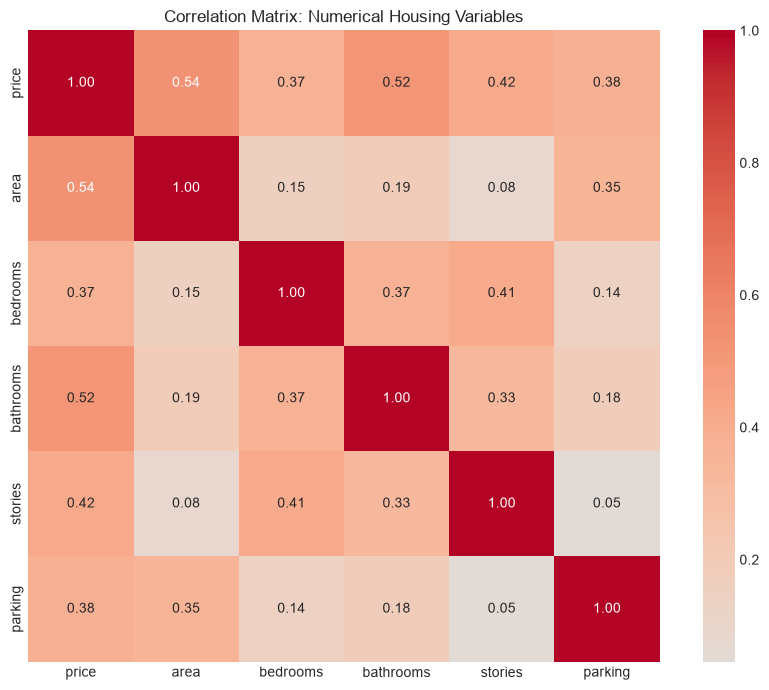

,Correlation with price
area,0.536
bathrooms,0.518
stories,0.421
parking,0.384
bedrooms,0.366


The strongest numerical association with `price` is `area` (0.536). Smaller absolute values indicate weaker linear associations with the target in this sample.

In [11]:
correlation_matrix = model_df[numerical_columns].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title('Correlation Matrix: Numerical Housing Variables')
plt.tight_layout()
plt.show()

sorted_correlations = target_correlations.sort_values(ascending=False)
display(sorted_correlations.rename('Correlation with price').to_frame())
display(Markdown(
    f"The strongest numerical association with `price` is `{simple_feature}` ({target_correlations[simple_feature]:.3f}). "
    "Smaller absolute values indicate weaker linear associations with the target in this sample."
))


## 14. Multicollinearity

Multicollinearity occurs when predictors contain overlapping information. It can make coefficient estimates unstable even if predictive performance remains useful. The correlation matrix offers a first check; Variance Inflation Factor (VIF) quantifies how strongly each predictor is explained by the others. A common screening rule treats VIF above 5 as worth investigating and above 10 as potentially severe, but context matters.

In [12]:
# VIF is calculated on the encoded predictor matrix; an intercept is not included in this table.
vif_input = X_multiple.astype(float)
vif_table = pd.DataFrame({
    'Feature': vif_input.columns,
    'VIF': [variance_inflation_factor(vif_input.values, index) for index in range(vif_input.shape[1])]
}).sort_values('VIF', ascending=False)
display(vif_table.round(3))

high_vif = vif_table[vif_table['VIF'] > 5]
if high_vif.empty:
    vif_comment = 'No encoded predictor exceeds the screening threshold of 5 in this calculation.'
else:
    vif_comment = 'Predictors above 5 should be interpreted with care: ' + ', '.join(high_vif['Feature'].tolist()) + '.'
display(Markdown(vif_comment + ' VIF is a diagnostic, not proof that a feature must be removed.'))


,Feature,VIF
12,furnishingstatus_unfurnished,1.674
11,furnishingstatus_semi-furnished,1.578
3,stories,1.478
1,bedrooms,1.369
0,area,1.325
7,basement_yes,1.323
2,bathrooms,1.287
6,guestroom_yes,1.213
4,parking,1.213
9,airconditioning_yes,1.212


No encoded predictor exceeds the screening threshold of 5 in this calculation. VIF is a diagnostic, not proof that a feature must be removed.

## 15. Linear Regression Assumptions

Major assumptions are: (1) a roughly linear mean relationship, (2) independent observations/errors, (3) approximately constant residual variance (homoscedasticity), (4) residuals that are reasonably normal for inference, and (5) no severe multicollinearity. The plots below are diagnostic evidence, not definitive proof. Independence also depends on how the data was collected and cannot be verified from these plots alone.

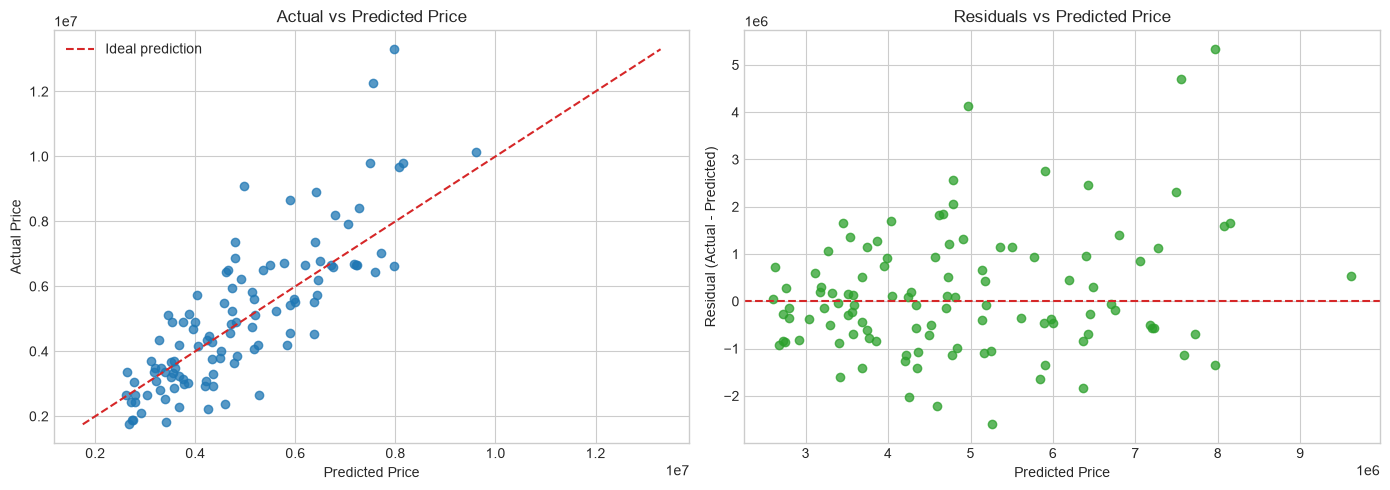

Inspect the residual plot for a random horizontal band around zero and broadly similar spread across fitted values. Visible structure, curvature, or a funnel shape would suggest that linearity or constant variance may be imperfect. The actual-vs-predicted plot shows how closely held-out predictions follow the ideal diagonal.

In [13]:
residuals = y_multiple_test - multiple_predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(multiple_predictions, y_multiple_test, alpha=0.75, color='#1f77b4')
line_min = min(multiple_predictions.min(), y_multiple_test.min())
line_max = max(multiple_predictions.max(), y_multiple_test.max())
axes[0].plot([line_min, line_max], [line_min, line_max], '--', color='#d62728', label='Ideal prediction')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Actual Price')
axes[0].set_title('Actual vs Predicted Price')
axes[0].legend()

axes[1].scatter(multiple_predictions, residuals, alpha=0.75, color='#2ca02c')
axes[1].axhline(0, color='#d62728', linestyle='--')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residuals vs Predicted Price')
plt.tight_layout()
plt.show()

display(Markdown(
    "Inspect the residual plot for a random horizontal band around zero and broadly similar spread across fitted values. "
    "Visible structure, curvature, or a funnel shape would suggest that linearity or constant variance may be imperfect. "
    "The actual-vs-predicted plot shows how closely held-out predictions follow the ideal diagonal."
))


## 16. Model Interpretation

The following concise interpretation is generated directly from the test metrics and diagnostics calculated above.

In [14]:
r2_change = multiple_metrics['R²'] - simple_metrics['R²']
display(Markdown(
    f"**Model performance:** {better_model} has the higher held-out R². The multiple model changes R² by {r2_change:.3f} relative to the simple model. "
    f"**Error meaning:** MAE ({multiple_metrics['MAE']:,.2f} for the multiple model) is the average absolute prediction error; MSE/RMSE penalize larger errors more strongly. "
    "**Influence:** inspect the coefficient table alongside feature units and the correlation/VIF diagnostics; coefficients are conditional associations rather than causal effects. "
    "**Limitations:** this is one train/test split, residual diagnostics are visual rather than formal tests, and the dataset's collection process affects independence and generalizability."
))


**Model performance:** Multiple Linear Regression has the higher held-out R². The multiple model changes R² by 0.380 relative to the simple model. **Error meaning:** MAE (970,043.40 for the multiple model) is the average absolute prediction error; MSE/RMSE penalize larger errors more strongly. **Influence:** inspect the coefficient table alongside feature units and the correlation/VIF diagnostics; coefficients are conditional associations rather than causal effects. **Limitations:** this is one train/test split, residual diagnostics are visual rather than formal tests, and the dataset's collection process affects independence and generalizability.

## 17. Key Findings

The bullet points below are computed from this executed notebook.

In [15]:
display(Markdown(
    f"- **Best held-out model:** {better_model} (R² = {comparison.loc[better_model, 'R²']:.3f}).\n"
    f"- **Simple model:** `{simple_feature}` predicts `price` with MAE = {simple_metrics['MAE']:,.2f} and RMSE = {simple_metrics['RMSE']:,.2f}.\n"
    f"- **Multiple model:** MAE = {multiple_metrics['MAE']:,.2f}, RMSE = {multiple_metrics['RMSE']:,.2f}, and R² = {multiple_metrics['R²']:.3f}.\n"
    f"- **Numerical correlation:** `{simple_feature}` has the strongest correlation with `price` ({target_correlations[simple_feature]:.3f}).\n"
    f"- **Multicollinearity:** {vif_comment}\n"
    "- **Limitation:** correlation and regression associations should not be interpreted as causal effects."
))


- **Best held-out model:** Multiple Linear Regression (R² = 0.653).
- **Simple model:** `area` predicts `price` with MAE = 1,474,748.13 and RMSE = 1,917,103.70.
- **Multiple model:** MAE = 970,043.40, RMSE = 1,324,506.96, and R² = 0.653.
- **Numerical correlation:** `area` has the strongest correlation with `price` (0.536).
- **Multicollinearity:** No encoded predictor exceeds the screening threshold of 5 in this calculation.
- **Limitation:** correlation and regression associations should not be interpreted as causal effects.

## 18. Conclusion

This project demonstrated both simple and multiple linear regression on the supplied housing data. The simple model provides a transparent baseline based on the strongest numerical association, while the multiple model incorporates the housing characteristics available in the dataset. Evaluation metrics, coefficient tables, correlation analysis, VIF, and residual diagnostics together support a more careful interpretation than a single score alone.

## 19. Interview Questions and Answers

**1. What assumptions does linear regression make?**  
It assumes a roughly linear relationship, independent errors, approximately constant error variance, reasonably normal residuals for inference, and no severe multicollinearity among predictors.

**2. How do you interpret coefficients?**  
A coefficient is the expected change in the target for a one-unit increase in that feature while other included predictors are held constant. Encoded categorical coefficients are relative to a reference category.

**3. What is R² and what does it signify?**  
R² is the proportion of variation in the target explained by the model on a given dataset. Higher is generally better, but it does not prove causality or guarantee performance on new data.

**4. When would you prefer MSE over MAE?**  
Prefer MSE when large errors deserve much stronger penalties, because squaring makes outliers more influential. MAE is easier to interpret and more robust to isolated large errors.

**5. How can you detect multicollinearity?**  
Inspect predictor correlations and calculate VIF. High absolute correlations or high VIF values indicate overlapping predictor information that may destabilize coefficients.

**6. What is the difference between simple and multiple linear regression?**  
Simple linear regression has one predictor; multiple linear regression has two or more. Multiple regression can account for several features simultaneously.

**7. Can linear regression be used for classification?**  
It is not the standard choice because its outputs are unbounded. Logistic regression and other classifiers are designed to model class probabilities and decision boundaries.

**8. What happens if regression assumptions are violated?**  
Predictions may be less accurate, coefficient estimates may be unstable or misleading, and statistical inference can become unreliable. Diagnostics, transformations, different features, or alternative models may help.